# Project 5 — Telco Customer Churn (Binary, Imbalanced)

**Goal:** predict whether a customer will churn (`Churn` = Yes/No) from account, service, and billing details.

**New skills beyond P1 Heart Disease:**
- Real **class imbalance** (~27% churn) -> SMOTE / class_weight, right metric (PR-AUC, recall)
- **Probability calibration** - does "70% risk" mean 70%?
- **Cost-based decision threshold** - keeping a customer is cheaper than losing one
- **Many categorical features** - encoding strategy

**Benchmark:** ~0.84-0.86 ROC-AUC. Real challenge = churn recall, not accuracy.

---
### How we work (interactive, chunk by chunk)
EDA -> Feature engineering -> Pipeline -> Model bake-off -> Imbalance -> Tuning -> Evaluation (+threshold/calibration) -> Rigor checks.

## -- EDA Step 1: First Look --
How many rows/columns, what types, and how balanced is the target?

In [158]:
# Get the data: one copy in THIS folder, no leftover cache.
# Uses kagglehub auth (no token), MOVES file out of cache, deletes cache.
# Re-runs are instant: if local file exists, skip download.
import os, glob, shutil
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns, warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

LOCAL = 'telco_churn.csv'
if not os.path.exists(LOCAL):
    import kagglehub
    cache = kagglehub.dataset_download('blastchar/telco-customer-churn')
    src   = glob.glob(os.path.join(cache, '*.csv'))[0]
    shutil.move(src, LOCAL)
    shutil.rmtree(cache, ignore_errors=True)
    print('Downloaded, moved to working dir, cache cleaned ->', LOCAL)
else:
    print('Using existing local file:', LOCAL)

df = pd.read_csv(LOCAL)
print('Shape:', df.shape)

Using existing local file: telco_churn.csv
Shape: (7043, 21)


In [159]:
# Column types + target balance
print('--- Column types ---')
print(df.dtypes)

print('\n--- Target balance (Churn) ---')
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True).round(3))
print('\n~27% churn -> IMBALANCED -> later use PR-AUC / recall, not accuracy.')

--- Column types ---
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

--- Target balance (Churn) ---
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64

~27% churn -> IMBALANCED -> later use PR-AUC / recall, not accuracy.


In [160]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## -- EDA Step 1.5: Full Missingness Audit (NaN + blank strings) --

`df.isnull().sum()` misses blank/whitespace strings (the TotalCharges trap). This checks BOTH.

In [161]:
# Count empties across ALL columns: NaN AND blank/whitespace strings
report = []
for col in df.columns:
    n_nan = df[col].isna().sum()
    n_blank = (df[col].astype(str).str.strip() == '').sum() if df[col].dtype == object else 0
    tot = n_nan + n_blank
    report.append({'column': col, 'dtype': str(df[col].dtype),
                   'NaN': n_nan, 'blank_str': n_blank,
                   'total_missing': tot, 'pct': round(tot/len(df)*100, 2)})

audit = pd.DataFrame(report).sort_values('total_missing', ascending=False)
print(audit.to_string(index=False))
print('\nTakeaway: TotalCharges has 11 BLANK strings - hidden missingness pandas did not flag.')

          column   dtype  NaN  blank_str  total_missing  pct
    TotalCharges  object    0         11             11 0.16
      customerID  object    0          0              0 0.00
DeviceProtection  object    0          0              0 0.00
  MonthlyCharges float64    0          0              0 0.00
   PaymentMethod  object    0          0              0 0.00
PaperlessBilling  object    0          0              0 0.00
        Contract  object    0          0              0 0.00
 StreamingMovies  object    0          0              0 0.00
     StreamingTV  object    0          0              0 0.00
     TechSupport  object    0          0              0 0.00
    OnlineBackup  object    0          0              0 0.00
          gender  object    0          0              0 0.00
  OnlineSecurity  object    0          0              0 0.00
 InternetService  object    0          0              0 0.00
   MultipleLines  object    0          0              0 0.00
    PhoneService  object

## -- EDA Step 1.6: Apply the Cleaning Decisions --

The fixes we reasoned out together:
1. `TotalCharges` text -> numeric (blanks become NaN)
2. Those NaN are all `tenure == 0` (brand-new, never billed) -> fill with **0** (domain logic, not median)
3. Drop `customerID` (identifier, no predictive value)
4. Encode target `Churn`: Yes -> 1 (the **positive** class = churn), No -> 0

> Why encode the target: recall/precision/PR-AUC and the churn threshold all need to know which class is "positive." Mapping Yes->1 makes it explicit.

In [162]:
# Apply the cleaning decisions
# 1. TotalCharges: text -> numeric (blank strings become NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 2. The NaN are all tenure==0 customers -> charges should be 0 (domain reasoning)
print('Rows with NaN TotalCharges (expect all tenure == 0):')
print(df[df['TotalCharges'].isna()][['tenure', 'MonthlyCharges', 'TotalCharges']])
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# 3. Drop the identifier
df = df.drop(columns=['customerID'])

# 4. Encode target (1 = churn = positive class)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print('\nAfter cleaning:')
print('  shape:', df.shape)
print('  total missing left:', int(df.isna().sum().sum()))
print('  Churn dtype:', df['Churn'].dtype, '| churn rate:', round(df['Churn'].mean(), 3))

Rows with NaN TotalCharges (expect all tenure == 0):
      tenure  MonthlyCharges  TotalCharges
488        0           52.55           NaN
753        0           20.25           NaN
936        0           80.85           NaN
1082       0           25.75           NaN
1340       0           56.05           NaN
3331       0           19.85           NaN
3826       0           25.35           NaN
4380       0           20.00           NaN
5218       0           19.70           NaN
6670       0           73.35           NaN
6754       0           61.90           NaN

After cleaning:
  shape: (7043, 20)
  total missing left: 0
  Churn dtype: int64 | churn rate: 0.265


## -- EDA Step 2: Numerical Distributions + Correlation --

Understand the numeric features (`tenure`, `MonthlyCharges`, `TotalCharges`) and how they relate to each other and to churn.

Verify (instead of eyeballing):
1. The **shape** of each numeric column (confirm skew / bimodal with `.skew()`).
2. The **multicollinearity** you suspected: `TotalCharges ~ tenure x MonthlyCharges`.

> Reminder: skew matters for LINEAR models, not trees. Note it now, decide transforms later by MEASURING.

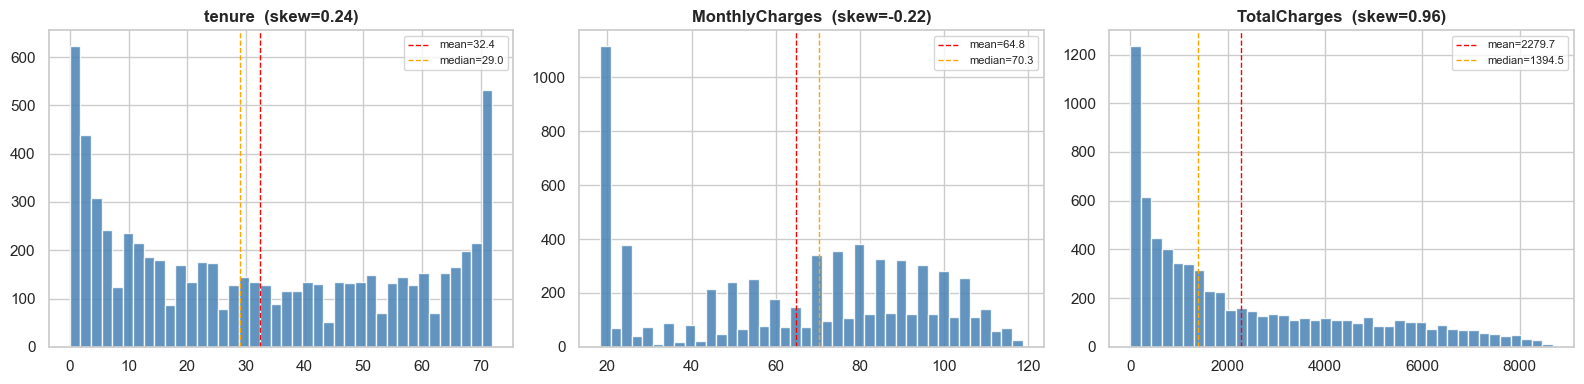

                  min     mean      50%      max
tenure           0.00    32.37    29.00    72.00
MonthlyCharges  18.25    64.76    70.35   118.75
TotalCharges     0.00  2279.73  1394.55  8684.80

Reading:
  tenure         -> bimodal (U-shape): many brand-new AND many loyal customers
  MonthlyCharges -> bimodal, min ~18 (NO zeros): cheap phone-only vs pricier bundles
  TotalCharges   -> right-skewed (= tenure x MonthlyCharges, inherits both)


In [163]:
# Distributions of the 3 numeric columns
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, num_cols):
    ax.hist(df[col], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(),   color='red',    ls='--', lw=1, label=f'mean={df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='orange', ls='--', lw=1, label=f'median={df[col].median():.1f}')
    ax.set_title(f'{col}  (skew={df[col].skew():.2f})', fontweight='bold')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print(df[num_cols].describe().round(2).T[['min', 'mean', '50%', 'max']])
print('\nReading:')
print('  tenure         -> bimodal (U-shape): many brand-new AND many loyal customers')
print('  MonthlyCharges -> bimodal, min ~18 (NO zeros): cheap phone-only vs pricier bundles')
print('  TotalCharges   -> right-skewed (= tenure x MonthlyCharges, inherits both)')

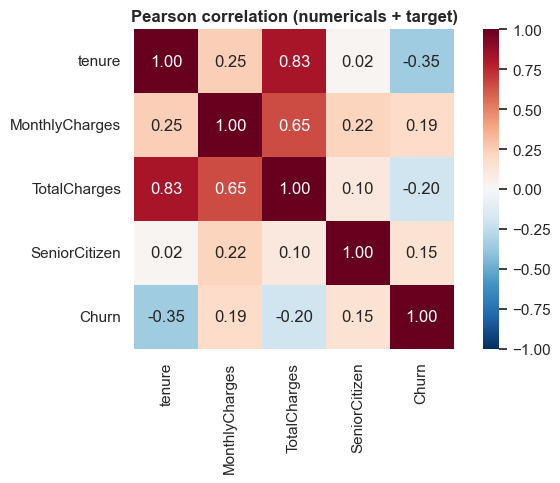

corr(TotalCharges, tenure * MonthlyCharges) = 1.000
-> Near 1.0 CONFIRMS TotalCharges is almost a product of the other two (redundant).
   Flag for later: high VIF -> may drop TotalCharges for LINEAR models (trees are fine).

Churn correlations: tenure negative (loyal=less churn), MonthlyCharges positive.


In [164]:
# Correlation heatmap (numericals + target)
corr_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title('Pearson correlation (numericals + target)', fontweight='bold')
plt.tight_layout(); plt.show()

# Verify the multicollinearity you suspected
product = df['tenure'] * df['MonthlyCharges']
r = np.corrcoef(product, df['TotalCharges'])[0, 1]
print(f'corr(TotalCharges, tenure * MonthlyCharges) = {r:.3f}')
print('-> Near 1.0 CONFIRMS TotalCharges is almost a product of the other two (redundant).')
print('   Flag for later: high VIF -> may drop TotalCharges for LINEAR models (trees are fine).')
print('\nChurn correlations: tenure negative (loyal=less churn), MonthlyCharges positive.')

## -- EDA Step 3: Categorical Features vs Churn (the real story) --

Most Telco features are categorical (Contract, services, payment method). This is where churn actually lives.

**Why we keep them as text (not encode now):** EDA is for understanding -> readable labels matter. Categorical features are tested with **chi-square + Cramer's V** (which work on the raw categories), while numeric features used correlation in Step 2. Encoding (OneHotEncoder) is a *modeling* step done later, inside the pipeline, after the split (to avoid leakage).

For each categorical feature we measure two things together:
- **Chi-square p-value** -> is it associated with churn at all? (is the pattern real?)
- **Cramer's V** -> how STRONG is that association? (effect size, 0 to 1)

**How to read the bar charts below:**
- The **red dashed line = overall churn rate (~27%)** across all customers.
- Each **bar = churn rate inside that one category**.
- **Bar ABOVE the line (red) = churns more than average = risk group.** Bar BELOW (blue) = safer.
- Bigger gap from the line = stronger churn driver.

> Rule: significance != strength. A tiny p-value on 7,000 rows is easy; Cramer's V tells us which features *matter*.

In [165]:
# Rank every categorical feature by its association with churn
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    r, k = ct.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

# SeniorCitizen is 0/1 -> treat as categorical too
cat_cols = df.select_dtypes(include='object').columns.tolist() + ['SeniorCitizen']

rows = []
for col in cat_cols:
    ct = pd.crosstab(df[col], df['Churn'])
    chi2, p, _, _ = chi2_contingency(ct)
    v = cramers_v(df[col], df['Churn'])
    eff = 'strong' if v >= 0.3 else ('moderate' if v >= 0.15 else ('weak' if v >= 0.05 else 'negligible'))
    rows.append({'feature': col, 'chi2': round(chi2, 1), 'p_value': p,
                 'cramers_v': round(v, 3), 'effect': eff})

assoc = pd.DataFrame(rows).sort_values('cramers_v', ascending=False)
print(assoc.to_string(index=False))
print('\nTop drivers = highest Cramers V. Negligible ones (e.g. gender, PhoneService) add little.')

         feature   chi2       p_value  cramers_v     effect
        Contract 1184.6 5.863038e-258      0.410     strong
  OnlineSecurity  850.0 2.661150e-185      0.347     strong
     TechSupport  828.2 1.443084e-180      0.343     strong
 InternetService  732.3 9.571788e-160      0.322     strong
   PaymentMethod  648.1 3.682355e-140      0.303     strong
    OnlineBackup  601.8 2.079759e-131      0.292   moderate
DeviceProtection  558.4 5.505219e-122      0.282   moderate
     StreamingTV  374.2  5.528994e-82      0.231   moderate
 StreamingMovies  375.7  2.667757e-82      0.231   moderate
PaperlessBilling  258.3  4.073355e-58      0.191   moderate
      Dependents  189.1  4.924922e-43      0.164   moderate
         Partner  158.7  2.139911e-36      0.150   moderate
   SeniorCitizen  159.4  1.510067e-36      0.150   moderate
   MultipleLines   11.3  3.464383e-03      0.040 negligible
    PhoneService    0.9  3.387825e-01      0.011 negligible
          gender    0.5  4.865787e-01   

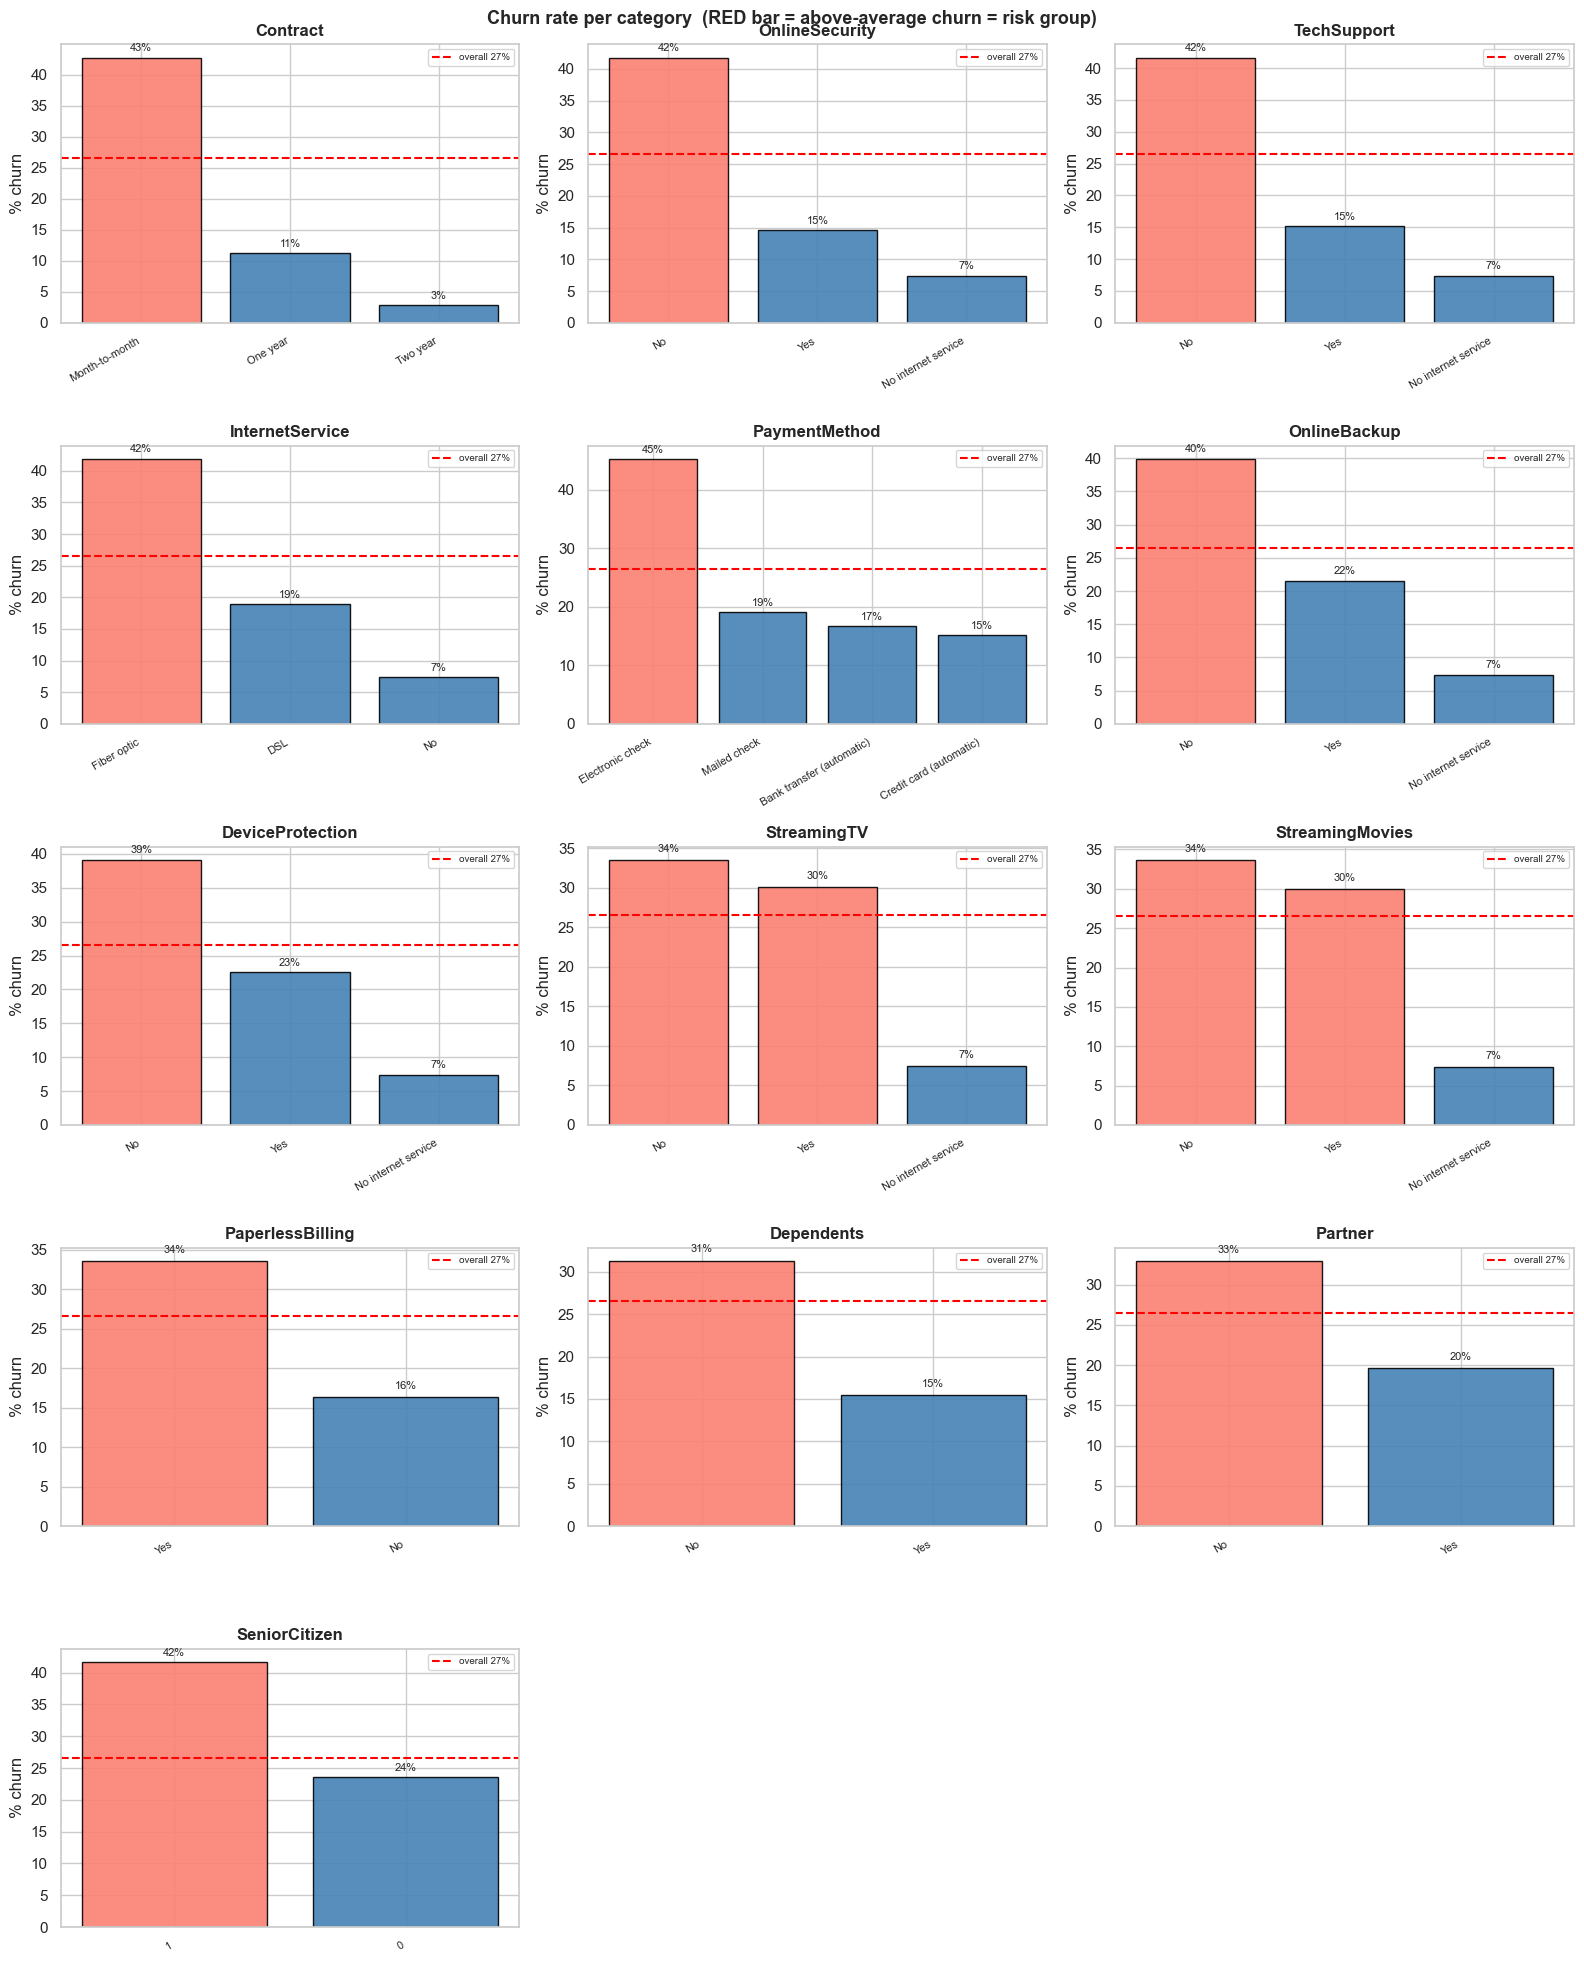

Read each chart: how far is a bar from the red 27% line?
Big gap above = that category strongly drives churn (e.g. Month-to-month contracts).


In [166]:
# Churn rate per category for the strongest drivers
top_feats = assoc[assoc['cramers_v'] >= 0.10]['feature'].tolist()
overall = df['Churn'].mean() * 100      # overall churn rate as a percentage

n = len(top_feats); ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = np.array(axes).flatten()

for ax, col in zip(axes, top_feats):
    rate = df.groupby(col)['Churn'].mean().sort_values(ascending=False) * 100
    # red = above-average churn (risk), blue = below average (safer)
    colors = ['salmon' if v > overall else 'steelblue' for v in rate.values]
    ax.bar(range(len(rate)), rate.values, color=colors, edgecolor='black', alpha=0.9)
    ax.axhline(overall, color='red', ls='--', lw=1.5, label=f'overall {overall:.0f}%')
    for i, v in enumerate(rate.values):
        ax.text(i, v + 1, f'{v:.0f}%', ha='center', fontsize=8)
    ax.set_xticks(range(len(rate)))
    ax.set_xticklabels(rate.index, rotation=30, ha='right', fontsize=8)
    ax.set_title(col, fontweight='bold'); ax.set_ylabel('% churn'); ax.legend(fontsize=7)

for ax in axes[n:]:
    ax.set_visible(False)
plt.suptitle('Churn rate per category  (RED bar = above-average churn = risk group)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print('Read each chart: how far is a bar from the red 27% line?')
print('Big gap above = that category strongly drives churn (e.g. Month-to-month contracts).')

## -- EDA Step 4: Feature Engineering --

Turn EDA findings into new features. Each one is justified by something we saw:

| New feature | From | Why |
|---|---|---|
| `tenure_group` | bin tenure | tenure is non-linear (new vs loyal) |
| `num_services` | count add-on services | more services = stickier = less churn |
| `has_security_or_support` | OnlineSecurity / TechSupport | strong churn reducers in EDA |
| `auto_payment` | PaymentMethod | electronic check churns; auto-payers stay |

Plus cleanup: collapse the redundant `"No internet service"` / `"No phone service"` value to `"No"`.

> **Leakage note:** these are all row-by-row transforms (binning, counting, flags) - they do NOT learn a statistic from data, so they are SAFE to do before the train/test split (like extracting Title in Titanic). Imputation/scaling/encoding come later, inside the pipeline.

In [167]:
# Build engineered features (all row-by-row -> safe before split)
df_fe = df.copy()

# -- Cleanup: collapse redundant "No internet/phone service" -> "No" --
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
                'StreamingTV', 'StreamingMovies', 'MultipleLines']
for c in service_cols:
    df_fe[c] = df_fe[c].replace({'No internet service': 'No', 'No phone service': 'No'})

# -- 1. tenure_group: bin the non-linear tenure --
df_fe['tenure_group'] = pd.cut(df_fe['tenure'], bins=[-1, 12, 24, 48, 72],
                               labels=['0-1yr', '1-2yr', '2-4yr', '4-6yr'])

# -- 2. num_services: how many add-on services the customer has --
addons = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
          'StreamingTV', 'StreamingMovies']
df_fe['num_services'] = (df_fe[addons] == 'Yes').sum(axis=1)

# -- 3. has_security_or_support: the two strongest churn-reducers --
df_fe['has_security_or_support'] = (
    (df_fe['OnlineSecurity'] == 'Yes') | (df_fe['TechSupport'] == 'Yes')
).astype(int)

# -- 4. auto_payment: automatic methods vs manual (electronic/mailed check) --
df_fe['auto_payment'] = df_fe['PaymentMethod'].isin(
    ['Bank transfer (automatic)', 'Credit card (automatic)']
).astype(int)

print('New features added:', ['tenure_group', 'num_services', 'has_security_or_support', 'auto_payment'])
print(df_fe[['tenure', 'tenure_group', 'num_services', 'has_security_or_support', 'auto_payment']].head())

New features added: ['tenure_group', 'num_services', 'has_security_or_support', 'auto_payment']
   tenure tenure_group  num_services  has_security_or_support  auto_payment
0       1        0-1yr             1                        0             0
1      34        2-4yr             2                        1             0
2       2        0-1yr             2                        1             0
3      45        2-4yr             3                        1             1
4       2        0-1yr             0                        0             0


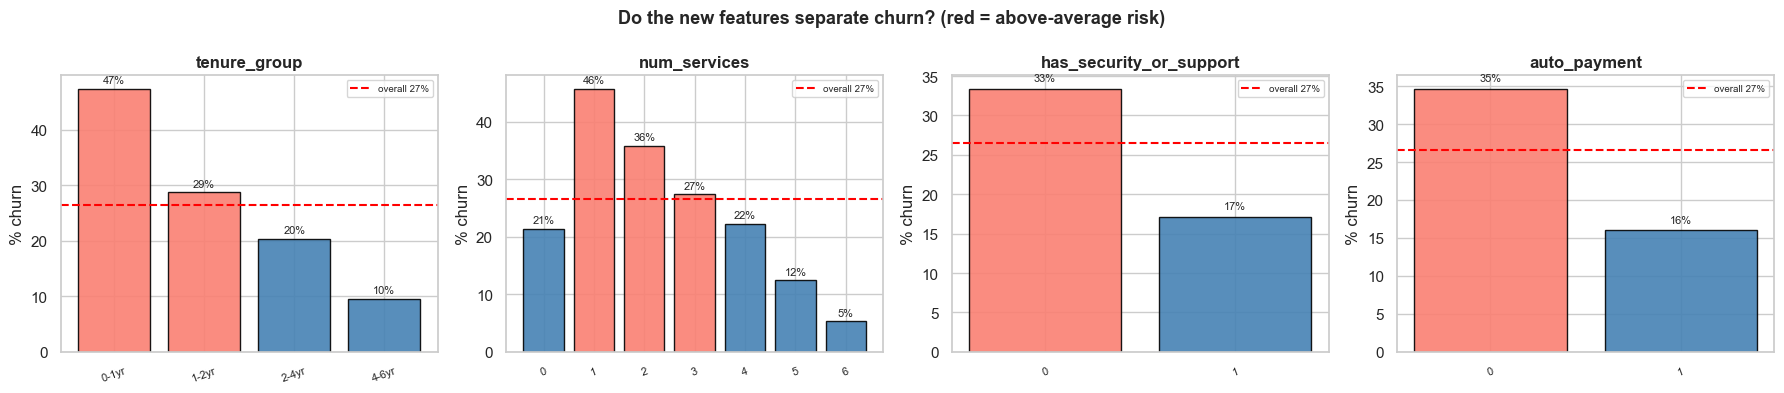

A useful feature shows a clear gradient or gap vs the red line.
num_services: more services -> lower churn? has_security_or_support: should be much lower.


In [168]:
# Validate: does each new feature actually separate churn?
overall = df_fe['Churn'].mean() * 100
new_feats = ['tenure_group', 'num_services', 'has_security_or_support', 'auto_payment']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, new_feats):
    rate = df_fe.groupby(col)['Churn'].mean() * 100
    colors = ['salmon' if v > overall else 'steelblue' for v in rate.values]
    ax.bar(range(len(rate)), rate.values, color=colors, edgecolor='black', alpha=0.9)
    ax.axhline(overall, color='red', ls='--', lw=1.5, label=f'overall {overall:.0f}%')
    for i, v in enumerate(rate.values):
        ax.text(i, v + 1, f'{v:.0f}%', ha='center', fontsize=8)
    ax.set_xticks(range(len(rate)))
    ax.set_xticklabels(rate.index, rotation=20, fontsize=8)
    ax.set_title(col, fontweight='bold'); ax.set_ylabel('% churn'); ax.legend(fontsize=7)
plt.suptitle('Do the new features separate churn? (red = above-average risk)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print('A useful feature shows a clear gradient or gap vs the red line.')
print('num_services: more services -> lower churn? has_security_or_support: should be much lower.')

## -- EDA Step 4.5: Interaction Check (does Contract's effect depend on X?) --

Your idea: split a strong feature (Contract) by another variable and see if risk changes.
That is an **interaction** test. We try Contract x [gender, SeniorCitizen, tenure_group].

**How to read the grouped bars below:**
- x-axis = Contract levels. Coloured bars = the second variable. Error bars = 95% CI.
- **If the coloured bars WITHIN a Contract level overlap -> no interaction** (that variable adds nothing here).
- **If they separate clearly -> real interaction** -> worth making a combined feature.

**Expectations (predict, then verify):**
- `gender`: ~zero main effect in EDA -> bars should overlap -> likely NO interaction (a useful negative result).
- `SeniorCitizen`: had a real effect -> maybe separates.
- `tenure_group`: strong, but already correlated with Contract -> separation may be redundant.

> Note: tree models find interactions automatically. Hand-built interaction features mainly help LINEAR models. So we only CREATE one if the split is clearly meaningful.

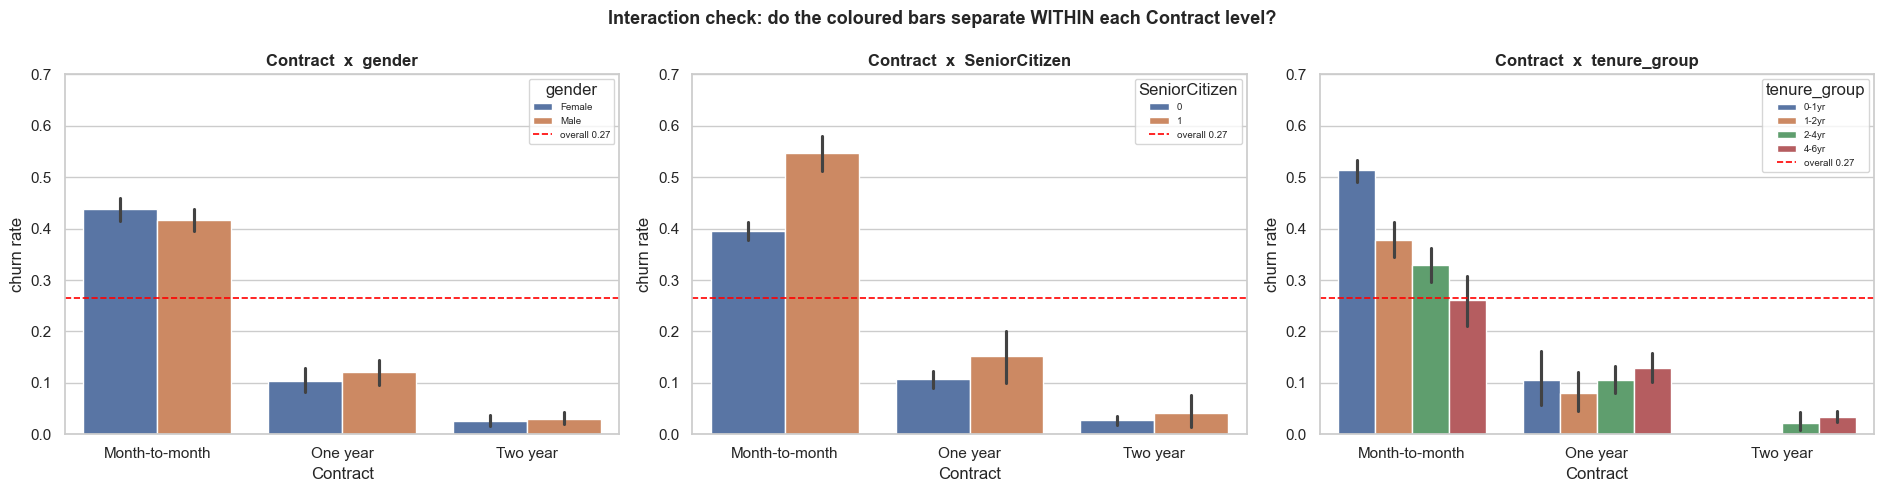

Decision rule:
  bars overlap within a Contract level -> NO interaction -> do not build the feature
  bars clearly separate              -> real interaction -> worth a combined feature


In [169]:
# Interaction check: Contract split by gender / SeniorCitizen / tenure_group
overall = df_fe['Churn'].mean()

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
for ax, var in zip(axes, ['gender', 'SeniorCitizen', 'tenure_group']):
    sns.barplot(data=df_fe, x='Contract', y='Churn', hue=var,
                errorbar=('ci', 95), ax=ax)
    ax.axhline(overall, color='red', ls='--', lw=1.2, label=f'overall {overall:.2f}')
    ax.set_title(f'Contract  x  {var}', fontweight='bold')
    ax.set_ylabel('churn rate'); ax.set_ylim(0, 0.7)
    ax.legend(fontsize=7, title=var)
plt.suptitle('Interaction check: do the coloured bars separate WITHIN each Contract level?',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print('Decision rule:')
print('  bars overlap within a Contract level -> NO interaction -> do not build the feature')
print('  bars clearly separate              -> real interaction -> worth a combined feature')

In [170]:
# Quantify it: how much does the 2nd variable move churn WITHIN each Contract level?
# We measure the spread (max - min churn rate) the variable introduces inside each Contract group.
for var in ['gender', 'SeniorCitizen', 'tenure_group']:
    g = df_fe.groupby(['Contract', var])['Churn'].mean().unstack()
    spread = (g.max(axis=1) - g.min(axis=1))     # within-Contract spread caused by var
    print(f'{var:>14}: avg within-Contract churn spread = {spread.mean():.3f}  (per level: {spread.round(2).to_dict()})')

print('\nBigger spread = stronger interaction. A spread near 0 (e.g. gender) = no interaction -> drop the idea.')

        gender: avg within-Contract churn spread = 0.014  (per level: {'Month-to-month': 0.02, 'One year': 0.02, 'Two year': 0.0})
 SeniorCitizen: avg within-Contract churn spread = 0.070  (per level: {'Month-to-month': 0.15, 'One year': 0.05, 'Two year': 0.01})
  tenure_group: avg within-Contract churn spread = 0.112  (per level: {'Month-to-month': 0.25, 'One year': 0.05, 'Two year': 0.03})

Bigger spread = stronger interaction. A spread near 0 (e.g. gender) = no interaction -> drop the idea.


## -- EDA Step 4.6: Systematic Interaction Scan + Tenure View --

Instead of checking interactions one-by-one, **scan them all at once**: pair Contract with every
other feature and rank by how much that partner moves churn WITHIN each Contract level
(the "within-Contract spread" metric). Bigger spread = stronger interaction.

Then a focused **tenure view**: churn vs tenure, split by Contract - the cleanest way to see
"does staying longer reduce risk, and does that depend on the contract type?"

> Honest caveat: the more you split (Contract x A x tenure), the smaller each cell gets -> noisier.
> And TREE models find interactions automatically. So this is mainly to UNDERSTAND the data; for the
> model we let trees do the work and only hand-build an interaction feature if it is clearly strong.

In [171]:
# Systematic scan: pair Contract with EVERY other feature, ranked by interaction strength
partners = [c for c in df_fe.select_dtypes(include='object').columns if c != 'Contract']
partners += ['SeniorCitizen', 'tenure_group', 'num_services']

rows = []
for var in partners:
    g = df_fe.groupby(['Contract', var])['Churn'].mean().unstack()
    spread = (g.max(axis=1) - g.min(axis=1)).mean()   # avg within-Contract churn spread
    rows.append({'partner_with_Contract': var, 'within_contract_spread': round(spread, 3)})

scan_df = pd.DataFrame(rows).sort_values('within_contract_spread', ascending=False)
print(scan_df.to_string(index=False))
print('\nBigger spread = that partner changes churn MORE within a Contract level.')

# Concrete payoff: for the top 3 partners, the SAFEST vs RISKIEST combined segment
print('\nSafest vs riskiest  Contract + partner  segments (top 3 partners):')
for var in scan_df['partner_with_Contract'].head(3):
    seg = df_fe.groupby(['Contract', var])['Churn'].mean().mul(100)
    print(f'  {var:>16}:  safest {seg.idxmin()} = {seg.min():.0f}%   |   riskiest {seg.idxmax()} = {seg.max():.0f}%')

print('\nThis shows how combining columns carves out very-low and very-high risk groups.')

partner_with_Contract  within_contract_spread
      InternetService                   0.197
         num_services                   0.178
        PaymentMethod                   0.136
         tenure_group                   0.112
      StreamingMovies                   0.097
          StreamingTV                   0.095
     PaperlessBilling                   0.090
        SeniorCitizen                   0.070
          TechSupport                   0.065
        MultipleLines                   0.062
       OnlineSecurity                   0.057
           Dependents                   0.055
         OnlineBackup                   0.045
     DeviceProtection                   0.032
              Partner                   0.025
         PhoneService                   0.017
               gender                   0.014

Bigger spread = that partner changes churn MORE within a Contract level.

Safest vs riskiest  Contract + partner  segments (top 3 partners):
   InternetService:  safest ('

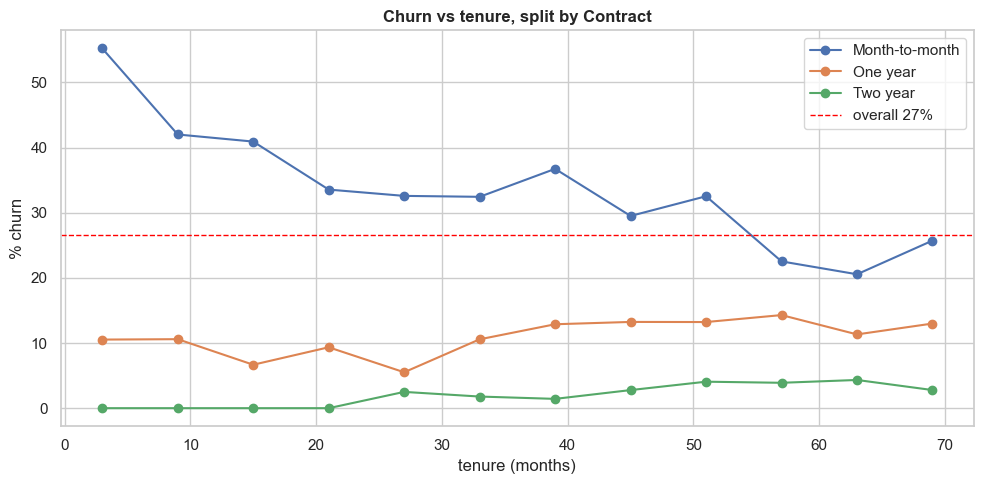

Read: all lines slope DOWN -> risk falls as customers stay longer.
Month-to-month starts highest and stays highest -> tenure helps but does not fully erase
the contract effect. The two signals are partly independent.


In [172]:
# Tenure view: does churn fall with tenure, and does it depend on Contract?
df_fe['_tb'] = pd.cut(df_fe['tenure'], bins=list(range(0, 73, 6)))
fig, ax = plt.subplots(figsize=(10, 5))
for contract in df_fe['Contract'].unique():
    sub = df_fe[df_fe['Contract'] == contract]
    rate = sub.groupby('_tb', observed=True)['Churn'].mean() * 100
    mids = [iv.mid for iv in rate.index]
    ax.plot(mids, rate.values, marker='o', label=contract)
ax.axhline(df_fe['Churn'].mean() * 100, color='red', ls='--', lw=1, label='overall 27%')
ax.set_xlabel('tenure (months)'); ax.set_ylabel('% churn')
ax.set_title('Churn vs tenure, split by Contract', fontweight='bold')
ax.legend()
plt.tight_layout(); plt.show()
df_fe.drop(columns='_tb', inplace=True)

print('Read: all lines slope DOWN -> risk falls as customers stay longer.')
print('Month-to-month starts highest and stays highest -> tenure helps but does not fully erase')
print('the contract effect. The two signals are partly independent.')

### NOTE - Leakage: which steps are safe before the split?

Two kinds of operations:

| Type | Examples | Safe BEFORE split? |
|---|---|---|
| **Row-by-row** (each row from itself only) | fixed-bin `tenure_group`, `num_services` count, Yes/No flags, ratios | YES |
| **Learns from data** (uses other rows / the target) | imputation median, scaling mean/std, OHE category set, **target/churn-rate encoding** | NO - must be inside the pipeline, after split |

So our Step 4 features were fine to build before the split (row-by-row). The churn rates in Steps 3-4.6
were only **looked at**, never fed in as features - if we had turned a segment's churn-rate into a column,
that is **target encoding** and would leak unless done inside CV.

> Stricter habit (what we did in P1): do EDA on `X_train` only, so even feature CHOICES are not influenced
> by the test set. Here we explored on the full frame - a mild relaxation, not model-fitting leakage.
>
> **Rule:** anything using the target or a cross-row statistic must live inside the pipeline, after the split.

## -- Step 5: Train/Test Split + Preprocessing Pipeline --

Now we convert object -> numeric. **The order is the lesson:**

1. **Split FIRST** (lock the test set away).
2. **Encode/scale INSIDE a pipeline**, fit on TRAIN only. OneHotEncoder learns the category set
   from training data; if we fit it on the full data we leak test info.

**Column groups:**
- **Numeric** (`StandardScaler`): tenure, MonthlyCharges, TotalCharges, num_services
- **Binary 0/1** (passthrough, already numeric): SeniorCitizen, has_security_or_support, auto_payment
- **Categorical** (`OneHotEncoder`): gender, Partner, services, Contract, PaymentMethod, tenure_group, ...

**Why OneHotEncoder (not manual mapping):** it turns each category into its own 0/1 column, learns the
categories on train, and `handle_unknown='ignore'` safely handles any category not seen in training.

> We keep both originals and engineered features for now (e.g. tenure AND tenure_group). Trees handle the
> redundancy; we will check feature importance later and prune if needed.

In [173]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# X / y  (use the feature-engineered frame; target is separate)
X = df_fe.drop(columns=['Churn'])
y = df_fe['Churn']

# Split FIRST - stratify keeps the 27% churn ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print('Train:', X_train.shape, '| Test:', X_test.shape)
print('Churn rate -> train:', round(y_train.mean(), 3), '| test:', round(y_test.mean(), 3))

# Column groups
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'num_services']
bin_cols = ['SeniorCitizen', 'has_security_or_support', 'auto_payment']   # already 0/1
cat_cols = [c for c in X.columns if c not in num_cols + bin_cols]

print('\nnum  (scale)      :', num_cols)
print('bin  (passthrough):', bin_cols)
print('cat  (one-hot)    :', cat_cols)

# Build the preprocessor (this is the object->numeric conversion, leakage-safe)
preprocessor = ColumnTransformer([
    ('num', StandardScaler(),                                        num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ('bin', 'passthrough',                                           bin_cols),
])
print('\nPreprocessor built. It will be fit on TRAIN only, inside the model pipeline.')

Train: (5634, 23) | Test: (1409, 23)
Churn rate -> train: 0.265 | test: 0.265

num  (scale)      : ['tenure', 'MonthlyCharges', 'TotalCharges', 'num_services']
bin  (passthrough): ['SeniorCitizen', 'has_security_or_support', 'auto_payment']
cat  (one-hot)    : ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group']

Preprocessor built. It will be fit on TRAIN only, inside the model pipeline.


In [174]:
# See what the encoder actually produces (fit on TRAIN only, just to inspect)
X_train_enc = preprocessor.fit_transform(X_train)
feat_names = preprocessor.get_feature_names_out()

print('Before encoding:', X_train.shape[1], 'columns')
print('After  encoding:', X_train_enc.shape[1], 'columns (each category became its own 0/1 column)')
print('\nSample of the new feature names:')
for nm in list(feat_names)[:20]:
    print('  ', nm)
print('\nNOTE: we did fit_transform here ONLY to look. In modeling we put `preprocessor`')
print('inside a Pipeline so cross-validation re-fits it on each fold (no leakage).')

Before encoding: 23 columns
After  encoding: 45 columns (each category became its own 0/1 column)

Sample of the new feature names:
   num__tenure
   num__MonthlyCharges
   num__TotalCharges
   num__num_services
   cat__gender_Female
   cat__gender_Male
   cat__Partner_No
   cat__Partner_Yes
   cat__Dependents_No
   cat__Dependents_Yes
   cat__PhoneService_No
   cat__PhoneService_Yes
   cat__MultipleLines_No
   cat__MultipleLines_Yes
   cat__InternetService_DSL
   cat__InternetService_Fiber optic
   cat__InternetService_No
   cat__OnlineSecurity_No
   cat__OnlineSecurity_Yes
   cat__OnlineBackup_No

NOTE: we did fit_transform here ONLY to look. In modeling we put `preprocessor`
inside a Pipeline so cross-validation re-fits it on each fold (no leakage).


## -- Step 6: Model Bake-off (with the right metric for imbalance) --

Baseline first, then several models with 5-fold CV.

**Metrics (why these):** data is imbalanced (~27% churn), so **accuracy lies** (predicting "no churn" for
everyone scores 73%). We rank by:
- **PR-AUC** (`average_precision`) - the honest metric when positives are rare
- **Recall** (churn caught) and **ROC-AUC** alongside

**Baseline:** `DummyClassifier` - any real model must clearly beat it.

> After the bake-off: a shallow **decision-tree visualization** so you can SEE the Contract -> tenure ->
> service splits the model finds on its own (the automatic version of your interaction hunting).

### NOTE - Why THESE models? (roster depends on dataset SIZE)

In P1 (303 rows) we tried ~12 models incl. SVM/KNN - everything is instant on tiny data. Telco has
**7,043 rows x ~30 features**, so the roster changes:

| Model | In? | Reason |
|---|---|---|
| LogReg, Decision Tree, Random Forest, Gradient Boosting, XGBoost | YES | cover linear / tree / bagging / boosting; fast at this size |
| **SVM (RBF)** | NO | kernel SVM is O(n^2)-O(n^3) -> slow on thousands of rows; `SVC(probability=True)` runs an internal CV for predict_proba -> very slow in our 5-fold x 4-metric loop |
| **KNN** | NO | slow + memory-heavy at predict time; rarely wins on tabular |
| **Naive Bayes** | NO | assumes feature independence - poor with one-hot-correlated service columns |
| **ExtraTrees / AdaBoost / LightGBM** | NO | near-duplicates of RF / GB / XGBoost - redundant |

> **Rule:** small data -> try everything. Larger data -> drop the slow (SVM-RBF, KNN) and the redundant
> (near-duplicate ensembles). If you DO want SVM at scale, use `LinearSVC` (fast) - but it has no
> predict_proba, so you must wrap it in `CalibratedClassifierCV` to get probabilities for PR-AUC.

In [175]:
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import time

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Dummy (baseline)':    DummyClassifier(strategy='most_frequent'),
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest':       RandomForestClassifier(random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=42),
}
try:
    from xgboost import XGBClassifier
    models['XGBoost'] = XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0)
except ImportError:
    print('xgboost not installed (skipped). pip install xgboost')

results = []
print(f"{'Model':<22}{'PR-AUC':>9}{'ROC-AUC':>9}{'Recall':>9}{'F1':>8}")
print('-' * 57)
for name, model in models.items():
    pipe = Pipeline([('pre', preprocessor), ('clf', model)])
    cvres = cross_validate(pipe, X_train, y_train, cv=cv,
                           scoring=['average_precision', 'roc_auc', 'recall', 'f1'], n_jobs=-1)
    r = {'Model': name,
         'PR-AUC':  cvres['test_average_precision'].mean(),
         'ROC-AUC': cvres['test_roc_auc'].mean(),
         'Recall':  cvres['test_recall'].mean(),
         'F1':      cvres['test_f1'].mean()}
    results.append(r)
    print(f"{name:<22}{r['PR-AUC']:>9.3f}{r['ROC-AUC']:>9.3f}{r['Recall']:>9.3f}{r['F1']:>8.3f}")

results_df = pd.DataFrame(results).sort_values('PR-AUC', ascending=False).reset_index(drop=True)
print('\nRanked by PR-AUC. Note Dummy: ROC-AUC=0.5, recall=0 -> a model must clearly beat this.')
print('Baseline PR-AUC ~= churn rate (0.27). ROC-AUC benchmark for this dataset ~0.84.')

Model                    PR-AUC  ROC-AUC   Recall      F1
---------------------------------------------------------
Dummy (baseline)          0.265    0.500    0.000   0.000
Logistic Regression       0.665    0.846    0.537   0.594
Decision Tree             0.614    0.830    0.538   0.575
Random Forest             0.610    0.821    0.478   0.543
Gradient Boosting         0.664    0.848    0.520   0.582
XGBoost                   0.622    0.822    0.512   0.560

Ranked by PR-AUC. Note Dummy: ROC-AUC=0.5, recall=0 -> a model must clearly beat this.
Baseline PR-AUC ~= churn rate (0.27). ROC-AUC benchmark for this dataset ~0.84.


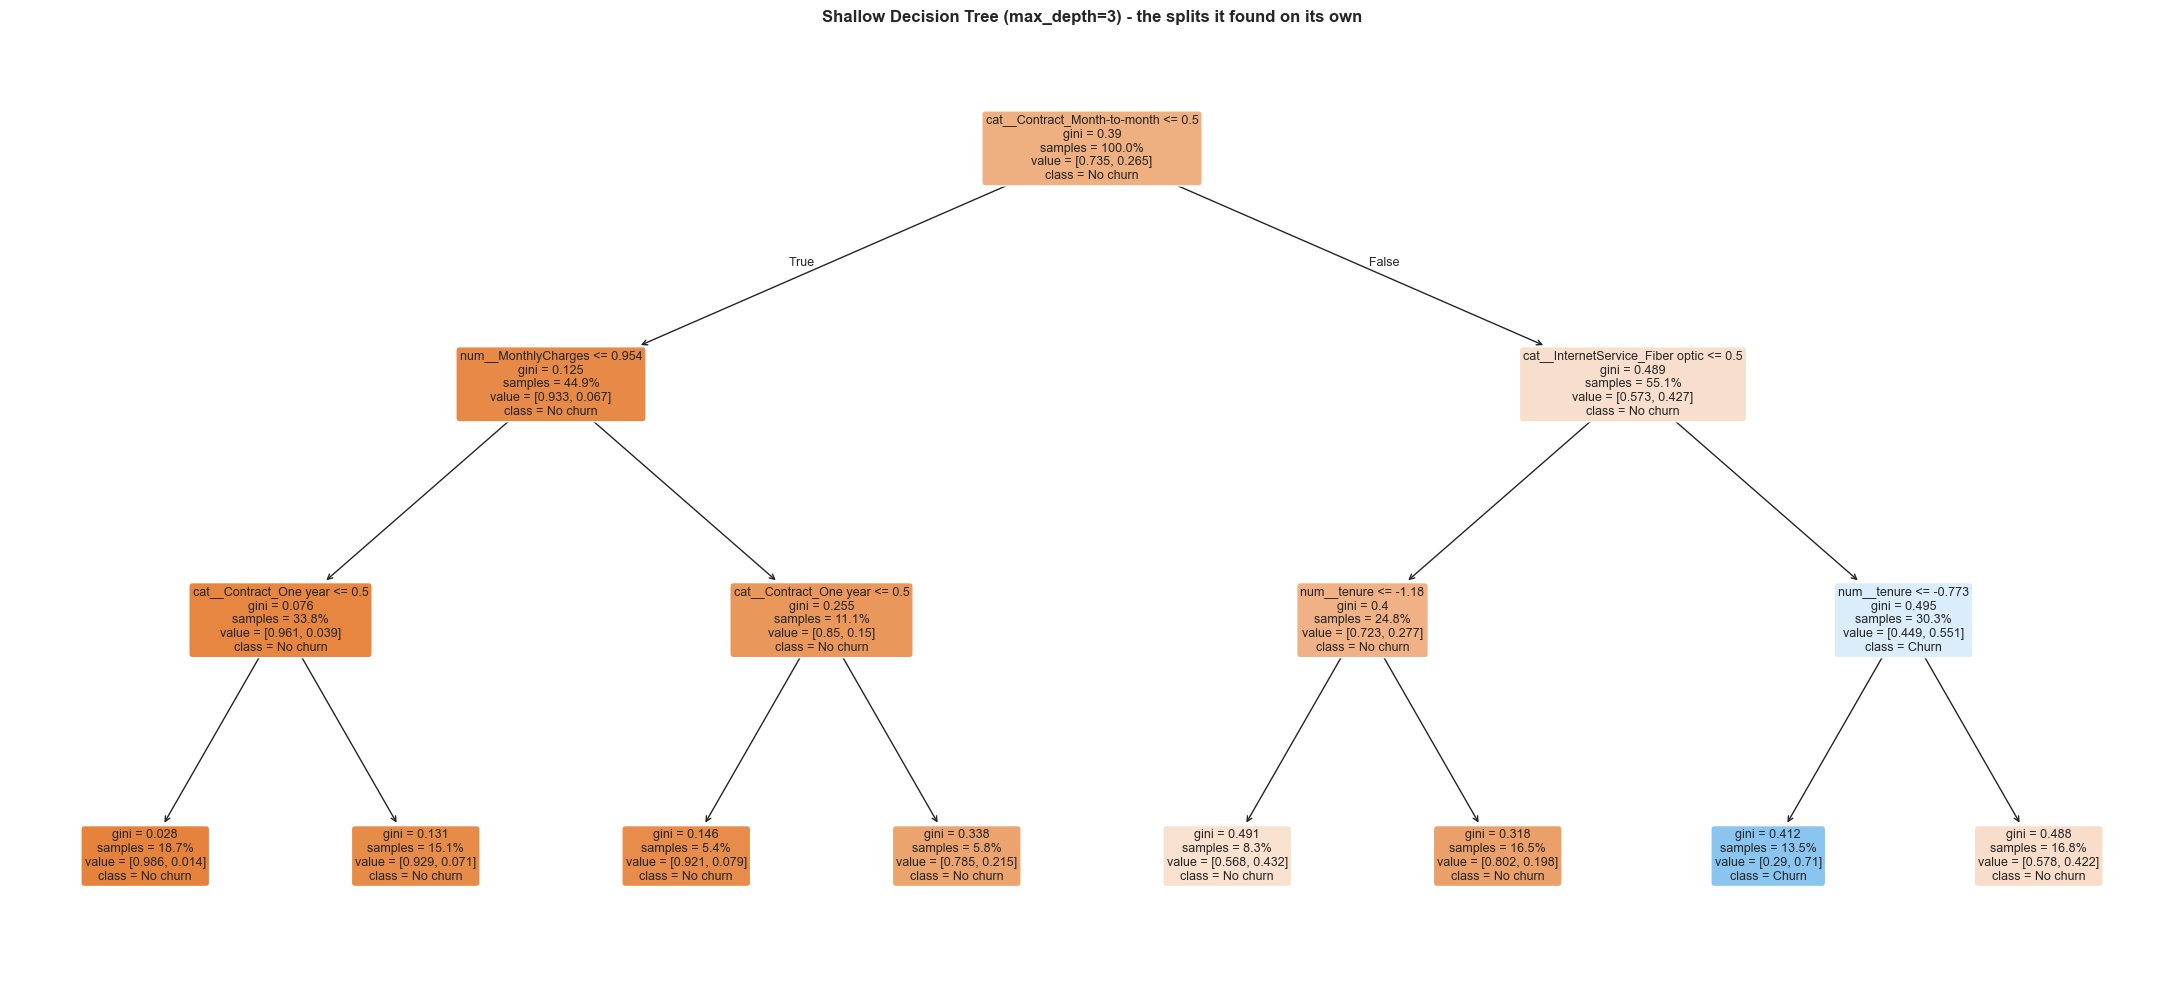

Read the top splits: the tree picks Contract / tenure / InternetService automatically -
exactly the interactions you were hunting by hand, but chosen optimally.


In [176]:
# Decision-tree visualization: SEE the splits the model picks automatically
from sklearn.tree import DecisionTreeClassifier, plot_tree

tree_pipe = Pipeline([('pre', preprocessor),
                      ('clf', DecisionTreeClassifier(max_depth=3, random_state=42))])
tree_pipe.fit(X_train, y_train)
feat_names = tree_pipe.named_steps['pre'].get_feature_names_out()

plt.figure(figsize=(22, 10))
plot_tree(tree_pipe.named_steps['clf'], feature_names=feat_names,
          class_names=['No churn', 'Churn'], filled=True, rounded=True,
          proportion=True, fontsize=9)
plt.title('Shallow Decision Tree (max_depth=3) - the splits it found on its own', fontweight='bold')
plt.tight_layout(); plt.show()

print('Read the top splits: the tree picks Contract / tenure / InternetService automatically -')
print('exactly the interactions you were hunting by hand, but chosen optimally.')

## -- Step 7: Imbalance Handling --

The bake-off showed decent ROC-AUC but **mediocre recall** - the model misses many churners at the
default 0.5 threshold. Three ways to fix it, compared on Logistic Regression:

1. **Baseline** - no handling (reference)
2. **class_weight='balanced'** - penalize missing a churner more (no extra data)
3. **SMOTE** - synthesize minority (churn) rows. MUST sit inside the pipeline so it only touches
   training folds (never the validation fold) - else leakage.

**What to watch:** recall should go UP, but precision usually goes DOWN (the trade-off). **PR-AUC**
is the overall summary; recall/precision show where the boundary moved.

> Honest insight: class_weight / SMOTE mostly **shift the decision boundary** - they often do NOT
> raise PR-AUC/ROC-AUC much. You can get a similar recall boost with **threshold tuning** (Step 9).
> So we measure all of them and keep what genuinely helps.

In [177]:
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.linear_model import LogisticRegression

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
SCORING = ['average_precision', 'roc_auc', 'recall', 'precision', 'f1']

strategies = {
    'LR baseline':     Pipeline([('pre', preprocessor),
                                  ('clf', LogisticRegression(max_iter=2000, random_state=42))]),
    'LR class_weight': Pipeline([('pre', preprocessor),
                                  ('clf', LogisticRegression(max_iter=2000, class_weight='balanced',
                                                             random_state=42))]),
}

# SMOTE strategy (needs imbalanced-learn; uses imblearn Pipeline so it runs train-folds only)
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    strategies['LR + SMOTE'] = ImbPipeline([
        ('pre', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('clf', LogisticRegression(max_iter=2000, random_state=42)),
    ])
except ImportError:
    print('imbalanced-learn not installed -> SMOTE skipped. Install: pip install imbalanced-learn')

rows = []
print(f"{'Strategy':<18}{'PR-AUC':>9}{'ROC-AUC':>9}{'Recall':>9}{'Precision':>11}{'F1':>8}")
print('-' * 64)
for name, pipe in strategies.items():
    r = cross_validate(pipe, X_train, y_train, cv=cv, scoring=SCORING, n_jobs=-1)
    row = {'Strategy': name,
           'PR-AUC':    r['test_average_precision'].mean(),
           'ROC-AUC':   r['test_roc_auc'].mean(),
           'Recall':    r['test_recall'].mean(),
           'Precision': r['test_precision'].mean(),
           'F1':        r['test_f1'].mean()}
    rows.append(row)
    print(f"{name:<18}{row['PR-AUC']:>9.3f}{row['ROC-AUC']:>9.3f}{row['Recall']:>9.3f}{row['Precision']:>11.3f}{row['F1']:>8.3f}")

imb_df = pd.DataFrame(rows)
print('\nRead it: recall should JUMP with class_weight/SMOTE, precision drops (trade-off).')
print('If PR-AUC barely changes -> the ranking is the same, only the boundary moved.')

Strategy             PR-AUC  ROC-AUC   Recall  Precision      F1
----------------------------------------------------------------
LR baseline           0.665    0.846    0.537      0.666   0.594
LR class_weight       0.665    0.846    0.796      0.517   0.627
LR + SMOTE            0.662    0.845    0.789      0.526   0.631

Read it: recall should JUMP with class_weight/SMOTE, precision drops (trade-off).
If PR-AUC barely changes -> the ranking is the same, only the boundary moved.


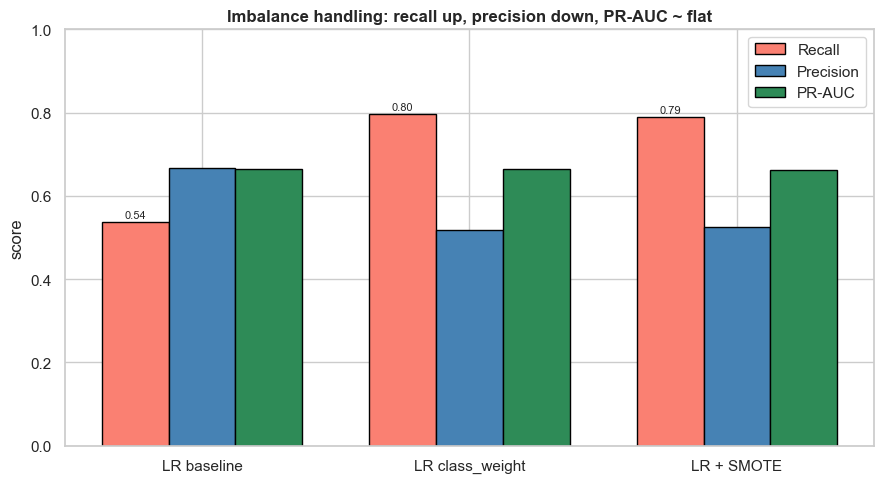

Takeaway: pick the strategy by PR-AUC (overall) + the recall you need for the business.
We carry the best forward to tuning (Step 8); final recall is set by threshold (Step 9).


In [178]:
# Visualize the recall <-> precision trade-off across strategies
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(imb_df)); w = 0.25
ax.bar(x - w, imb_df['Recall'],    w, label='Recall',    color='salmon',    edgecolor='black')
ax.bar(x,     imb_df['Precision'], w, label='Precision', color='steelblue', edgecolor='black')
ax.bar(x + w, imb_df['PR-AUC'],    w, label='PR-AUC',    color='seagreen',  edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels(imb_df['Strategy'])
ax.set_ylabel('score'); ax.set_ylim(0, 1); ax.legend()
ax.set_title('Imbalance handling: recall up, precision down, PR-AUC ~ flat', fontweight='bold')
for i, row in imb_df.iterrows():
    ax.text(i - w, row['Recall'] + 0.01, f"{row['Recall']:.2f}", ha='center', fontsize=8)
plt.tight_layout(); plt.show()

print('Takeaway: pick the strategy by PR-AUC (overall) + the recall you need for the business.')
print('We carry the best forward to tuning (Step 8); final recall is set by threshold (Step 9).')

### NOTE - How the modeling steps connect (each step's output feeds the next)

A model has many choices. We decide them in **stages**: each stage fixes ONE choice and passes it forward.

| Step | Question it answers | Output = a locked-in choice | Used by |
|---|---|---|---|
| 6 Bake-off | Which model family? | Logistic Regression is competitive | 7, 8 |
| 7 Imbalance | How to handle the 27/73 imbalance? | **`class_weight='balanced'`** (best recall, PR-AUC ~ same as SMOTE) | 8 |
| 8 Tuning | Given LR + class_weight, best `C` / `penalty` / `solver`? | tuned `best_lr` | 9 |
| 9 Threshold + calibration | Best decision cutoff + are probabilities honest? | final model + operating point | done |

**So Step 7 -> Step 8:** the `class_weight='balanced'` we picked in Step 7 is written into the
LogisticRegression that Step 8 tunes. Step 8 holds it FIXED and searches the remaining knobs.

**Is `class_weight` a tuning parameter?** Yes - it IS a hyperparameter. We just chose it **manually in
Step 7** (so we could SEE the recall/precision trade-off) instead of burying it in the Step 8 grid.
Equivalent alternative: skip Step 7 and add `clf__class_weight: [None, 'balanced']` to the grid.

**The mental model:** modeling = a chain of decisions, each narrowing the next.
`model family -> imbalance strategy -> hyperparameters -> threshold`. Nothing from an earlier step is
wasted; it becomes a fixed ingredient in the later steps.

## -- Step 8: Hyperparameter Tuning (LR + class_weight) --

We locked in **Logistic Regression with `class_weight='balanced'`**. Now tune its knobs with GridSearchCV.

| Knob | Meaning | Values |
|---|---|---|
| `C` | inverse regularization (low C = simpler/more shrinkage) | logspace(-3, 2) |
| `penalty` | l1 (sparse), l2 (shrink all), elasticnet (mix) | l1 / l2 / elasticnet |
| `solver` | liblinear (l1/l2), saga (elasticnet) | liblinear / saga |
| `l1_ratio` | elasticnet mix (saga only) | 0.25 / 0.5 / 0.75 |

**Scoring = `average_precision` (PR-AUC)** - we optimize for the imbalanced metric, not accuracy.
We keep `class_weight='balanced'` fixed (already chosen in Step 7).

> Expect a small gain. On clean tabular data, tuning LR usually moves PR-AUC by ~0.01. Confirming the
> default is near-optimal is a valid result. We also check if L1 zeroed out the redundant features.

In [179]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

lr_pipe = Pipeline([('pre', preprocessor),
                    ('clf', LogisticRegression(max_iter=3000, class_weight='balanced',
                                               random_state=42))])
Cs = np.logspace(-3, 2, 10)
param_grid = [
    {'clf__solver': ['liblinear'], 'clf__penalty': ['l1', 'l2'], 'clf__C': Cs},
    {'clf__solver': ['saga'], 'clf__penalty': ['elasticnet'],
     'clf__l1_ratio': [0.25, 0.5, 0.75], 'clf__C': Cs, 'clf__max_iter': [5000]},
]

grid = GridSearchCV(lr_pipe, param_grid, cv=cv, scoring='average_precision',
                    n_jobs=-1, refit=True)
print('Searching (every combination, scored on PR-AUC)...')
grid.fit(X_train, y_train)

print(f'\nBest PR-AUC (CV): {grid.best_score_:.4f}')
print('Best params:')
for k, v in grid.best_params_.items():
    print(f'  {k:<20} = {v}')

best_lr = grid.best_estimator_

Searching (every combination, scored on PR-AUC)...

Best PR-AUC (CV): 0.6645
Best params:
  clf__C               = 0.5994842503189409
  clf__l1_ratio        = 0.25
  clf__max_iter        = 5000
  clf__penalty         = elasticnet
  clf__solver          = saga


In [180]:
from sklearn.model_selection import cross_val_score

# Default (class_weight, C=1, l2) vs tuned - did tuning actually help?
default_lr = Pipeline([('pre', preprocessor),
                       ('clf', LogisticRegression(max_iter=3000, class_weight='balanced',
                                                  random_state=42))])
default_prauc = cross_val_score(default_lr, X_train, y_train, cv=cv,
                                scoring='average_precision', n_jobs=-1).mean()

print('Logistic Regression (class_weight) - Default vs Tuned, 5-fold PR-AUC:')
print(f'  Default (C=1, l2): {default_prauc:.4f}')
print(f'  Tuned:             {grid.best_score_:.4f}')
print(f'  Improvement:       {grid.best_score_ - default_prauc:+.4f}')
if grid.best_score_ - default_prauc < 0.005:
    print('  -> within noise: the default was already near-optimal (a valid finding).')

# Did L1 drop any features? (coefficients exactly 0)
clf = best_lr.named_steps['clf']
n_zero = int((clf.coef_[0] == 0).sum())
print(f'\nFeatures zeroed out by the penalty: {n_zero} of {clf.coef_.shape[1]}')
print('best_lr is ready -> Step 9 evaluates it on the locked test set (+ threshold + calibration).')

Logistic Regression (class_weight) - Default vs Tuned, 5-fold PR-AUC:
  Default (C=1, l2): 0.6645
  Tuned:             0.6645
  Improvement:       -0.0000
  -> within noise: the default was already near-optimal (a valid finding).

Features zeroed out by the penalty: 7 of 45
best_lr is ready -> Step 9 evaluates it on the locked test set (+ threshold + calibration).


## -- Step 9: Final Evaluation + Threshold Tuning + Calibration --

The test set has been LOCKED since Step 5. Now we use it ONCE. Three parts:

1. **Final evaluation** of the tuned model at the default 0.5 cutoff (confusion matrix, PR-AUC, ROC-AUC).
2. **Threshold tuning** - 0.5 is arbitrary; we pick the cutoff for the recall/precision the business wants.
3. **Calibration** - do the predicted probabilities mean what they say? (Important: `class_weight` distorts them.)

=== TEST SET (used once) - default threshold 0.5 ===
ROC-AUC: 0.8427 | PR-AUC: 0.6371
              precision    recall  f1-score   support

    No churn       0.90      0.72      0.80      1035
       Churn       0.50      0.79      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



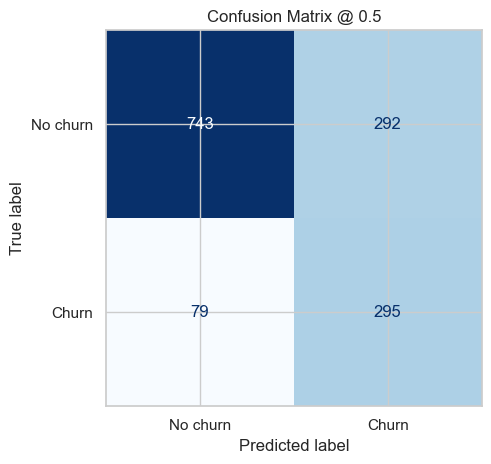

In [181]:
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, classification_report,
                             roc_auc_score, average_precision_score, precision_recall_curve)
from sklearn.linear_model import LogisticRegression

# Safety: if Step 8 was not run, fall back to the class_weight default
try:
    best_lr
except NameError:
    best_lr = Pipeline([('pre', preprocessor),
                        ('clf', LogisticRegression(max_iter=3000, class_weight='balanced',
                                                   random_state=42))]).fit(X_train, y_train)

y_prob = best_lr.predict_proba(X_test)[:, 1]      # P(churn)
y_pred = (y_prob >= 0.5).astype(int)              # default threshold

print('=== TEST SET (used once) - default threshold 0.5 ===')
print('ROC-AUC:', round(roc_auc_score(y_test, y_prob), 4),
      '| PR-AUC:', round(average_precision_score(y_test, y_prob), 4))
print(classification_report(y_test, y_pred, target_names=['No churn', 'Churn']))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                       display_labels=['No churn', 'Churn']).plot(cmap='Blues', colorbar=False)
plt.title('Confusion Matrix @ 0.5'); plt.tight_layout(); plt.show()

### NOTE - Threshold tuning (why 0.5 is arbitrary)

The model outputs a **probability** of churn. The 0.5 cutoff is just a default - nothing special.

- **Lower the threshold** -> predict churn more often -> **recall up, precision down** (catch more churners, more false alarms).
- **Raise it** -> the opposite.

For churn, a false negative (miss a leaver) usually costs more than a false positive (a needless retention offer),
so businesses often **lower** the threshold. We pick the cutoff deliberately:
- **F1-optimal** - best balance of precision and recall (a neutral default), OR
- **Target-recall** - the lowest threshold that still catches, say, 80% of churners (a business choice).

> This is the same lever as `class_weight`/SMOTE - all of them just move the decision boundary. We already
> applied class_weight, so the boundary is already recall-leaning; tuning may RAISE the threshold to win back precision.

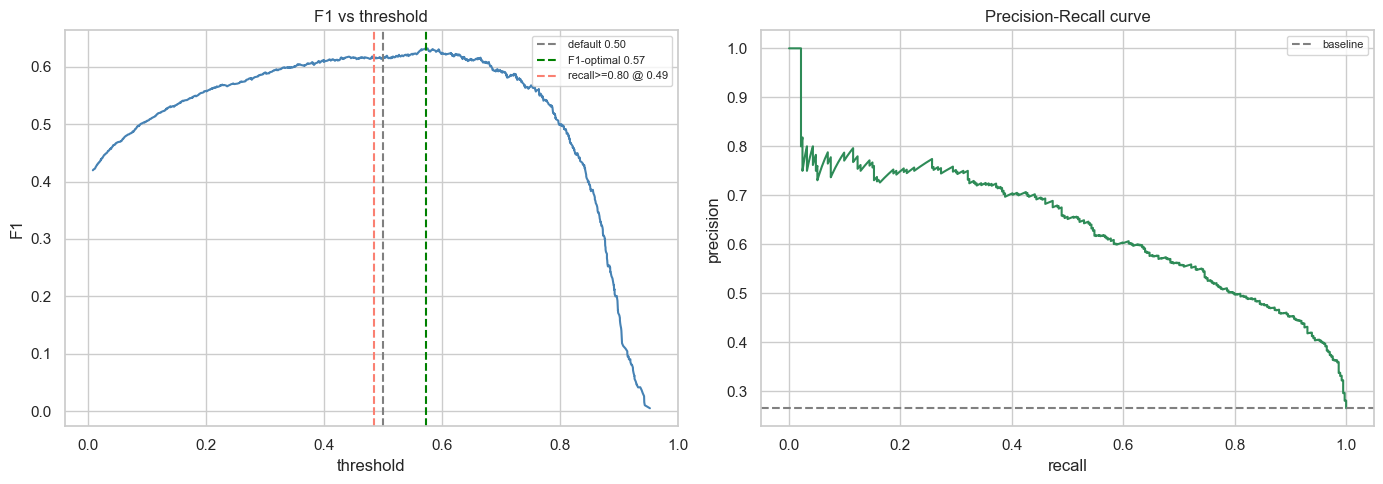

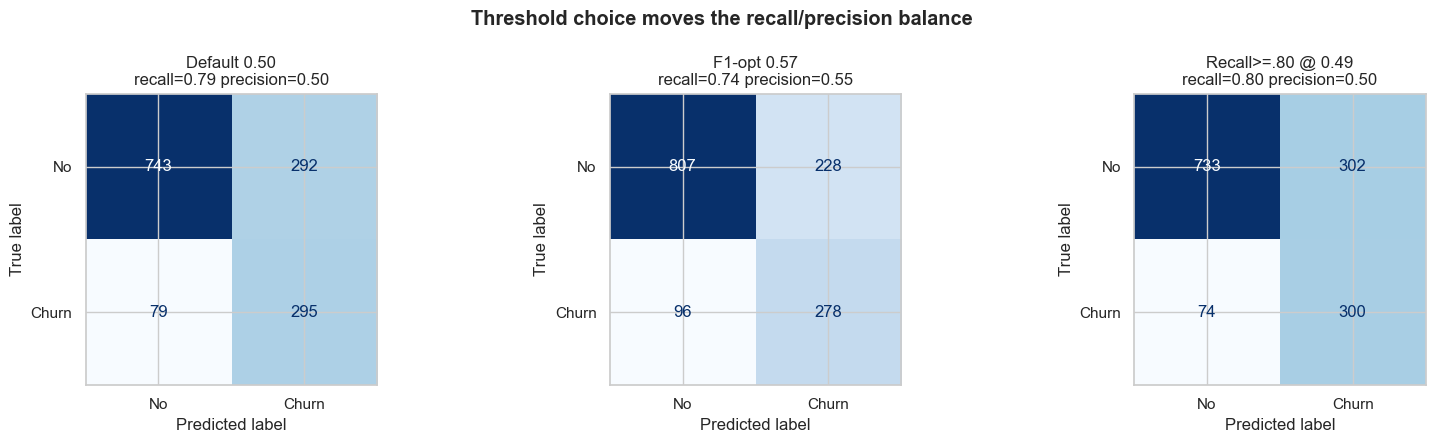

F1-optimal threshold = 0.57 | threshold for 80% recall = 0.49


In [182]:
prec, rec, thr = precision_recall_curve(y_test, y_prob)
f1 = 2 * prec * rec / (prec + rec + 1e-9)
f1_t = f1[:-1]                     # align with thr (precision_recall_curve returns len+1)
best_ix = int(np.argmax(f1_t))
best_t = thr[best_ix]

# target-recall threshold: lowest cutoff that still catches >= 80% of churners
target = 0.80
ok = np.where(rec[:-1] >= target)[0]
t_recall = thr[ok[-1]] if len(ok) else 0.0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(thr, f1_t, color='steelblue')
axes[0].axvline(0.5, color='grey', ls='--', label='default 0.50')
axes[0].axvline(best_t, color='green', ls='--', label=f'F1-optimal {best_t:.2f}')
axes[0].axvline(t_recall, color='salmon', ls='--', label=f'recall>=0.80 @ {t_recall:.2f}')
axes[0].set_xlabel('threshold'); axes[0].set_ylabel('F1'); axes[0].set_title('F1 vs threshold'); axes[0].legend(fontsize=8)
axes[1].plot(rec, prec, color='seagreen'); axes[1].set_xlabel('recall'); axes[1].set_ylabel('precision')
axes[1].set_title('Precision-Recall curve'); axes[1].axhline(y_test.mean(), color='grey', ls='--', label='baseline')
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

# Compare confusion matrices at the three thresholds
from sklearn.metrics import recall_score, precision_score
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (lab, t) in zip(axes, [('Default 0.50', 0.5),
                               (f'F1-opt {best_t:.2f}', best_t),
                               (f'Recall>=.80 @ {t_recall:.2f}', t_recall)]):
    yp = (y_prob >= t).astype(int)
    ConfusionMatrixDisplay(confusion_matrix(y_test, yp),
                           display_labels=['No', 'Churn']).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{lab}\nrecall={recall_score(y_test,yp):.2f} precision={precision_score(y_test,yp):.2f}')
plt.suptitle('Threshold choice moves the recall/precision balance', fontweight='bold')
plt.tight_layout(); plt.show()
print(f'F1-optimal threshold = {best_t:.2f} | threshold for 80% recall = {t_recall:.2f}')

### NOTE - Calibration (are the probabilities honest?)

A calibrated model means: of all customers it scored "70% churn", about 70% actually churn. This matters
if the business **acts on the probability** (e.g. spend retention budget proportional to risk).

**Plot:** predicted probability (x) vs actual churn fraction (y). Perfect = the diagonal.
**Brier score:** mean squared error of probabilities - lower = better calibrated.

> **Key caveat:** `class_weight='balanced'` (Step 7) deliberately INFLATES churn probabilities to boost recall.
> Great for the yes/no decision, but it makes the raw probabilities **over-forecast** churn -> poorly calibrated.
> Fix: wrap the model in `CalibratedClassifierCV`, which re-maps probabilities to be honest WITHOUT changing
> the ranking (ROC-AUC stays the same). So: if you only need a threshold decision, calibration is optional;
> if you need trustworthy probabilities, calibrate.

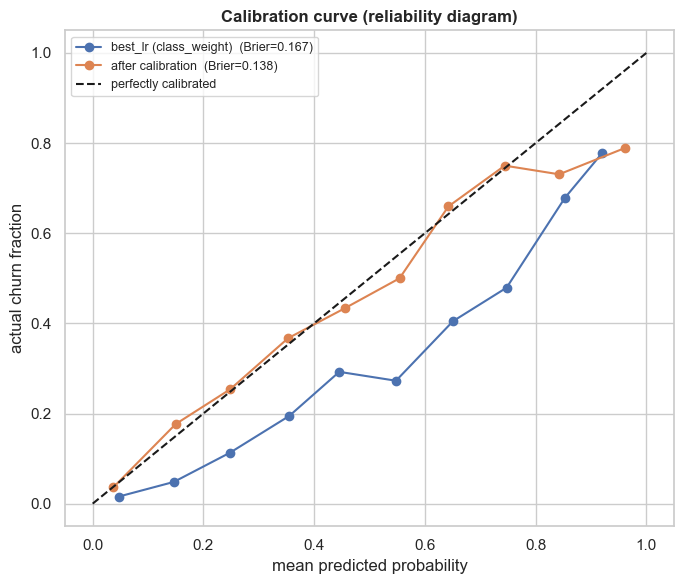

If the class_weight curve sits BELOW the diagonal -> it over-forecasts churn (expected).
Calibration pulls it onto the diagonal and lowers Brier, WITHOUT changing ROC-AUC:
  ROC-AUC raw       : 0.8427
  ROC-AUC calibrated: 0.8431


In [183]:
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import brier_score_loss

# Recalibrate the class_weight model (isotonic, cv on train) - fixes probabilities, keeps ranking
calibrated = CalibratedClassifierCV(best_lr, method='isotonic', cv=5)
calibrated.fit(X_train, y_train)
y_prob_cal = calibrated.predict_proba(X_test)[:, 1]

fig, ax = plt.subplots(figsize=(7, 6))
for lab, p in [('best_lr (class_weight)', y_prob), ('after calibration', y_prob_cal)]:
    fpos, mpred = calibration_curve(y_test, p, n_bins=10)
    ax.plot(mpred, fpos, marker='o', label=f'{lab}  (Brier={brier_score_loss(y_test, p):.3f})')
ax.plot([0, 1], [0, 1], 'k--', label='perfectly calibrated')
ax.set_xlabel('mean predicted probability'); ax.set_ylabel('actual churn fraction')
ax.set_title('Calibration curve (reliability diagram)', fontweight='bold'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print('If the class_weight curve sits BELOW the diagonal -> it over-forecasts churn (expected).')
print('Calibration pulls it onto the diagonal and lowers Brier, WITHOUT changing ROC-AUC:')
print('  ROC-AUC raw       :', round(roc_auc_score(y_test, y_prob), 4))
print('  ROC-AUC calibrated:', round(roc_auc_score(y_test, y_prob_cal), 4))

### NOTE - Did hyperparameter tuning help? (Barely - and that is expected)

Tuning moved ROC-AUC by ~0.00 (0.843 -> 0.843). On clean tabular data this is NORMAL: LogisticRegression's
defaults (C=1, l2) are already near-optimal. Confirming the default is good is a VALID result, not a failure.

**Where the real gains came from in this project:**

| Lever | Effect |
|---|---|
| Right metric (PR-AUC / recall) | stopped accuracy from hiding the imbalance problem |
| `class_weight='balanced'` | recall ~0.50 -> 0.79 (the big win - catching churners) |
| Threshold tuning | dial recall vs precision to the business need |
| Calibration | honest probabilities (Brier 0.167 -> 0.138), ranking unchanged |
| **Hyperparameter tuning** | **~0.00 - negligible** |

> **Playbook rule confirmed:** biggest gains come from the right metric, data/feature work, and the
> imbalance + threshold setup - NOT from hyperparameter tuning. Beginners over-invest in tuning;
> experienced practitioners invest in metric/data/setup.

## -- Step 10: Rigor & Honesty Checks --

Same template as P1. Make the result trustworthy, not just a single number.
1. **Distribution, not a point** - RepeatedStratifiedKFold (5x10), report mean +/- std of PR-AUC.
2. **Learning curve** - would more data help, or are we data-saturated?
3. **Validation curve over C** - see the overfit -> underfit arc on our own data.

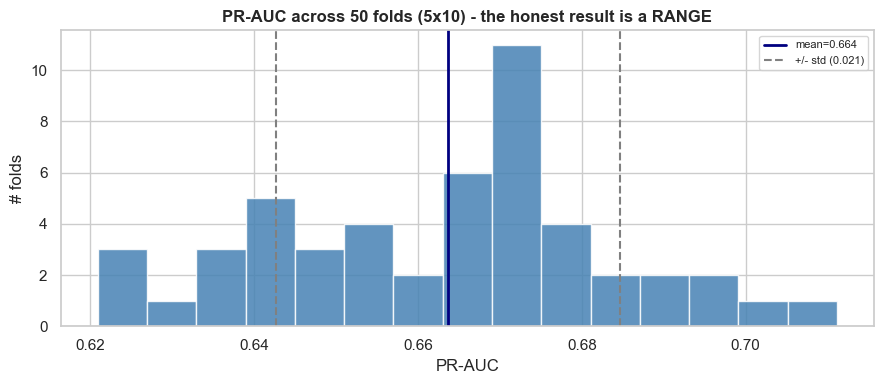

Honest headline: PR-AUC = 0.664 +/- 0.021


In [184]:
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score, learning_curve, validation_curve
from sklearn.linear_model import LogisticRegression

# 1. Distribution of PR-AUC across 50 folds (5x10)
rcv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)
prauc = cross_val_score(best_lr, X_train, y_train, cv=rcv, scoring='average_precision', n_jobs=-1)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(prauc, bins=15, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(prauc.mean(), color='navy', lw=2, label=f'mean={prauc.mean():.3f}')
ax.axvline(prauc.mean()-prauc.std(), color='grey', ls='--', label=f'+/- std ({prauc.std():.3f})')
ax.axvline(prauc.mean()+prauc.std(), color='grey', ls='--')
ax.set_xlabel('PR-AUC'); ax.set_ylabel('# folds'); ax.legend(fontsize=8)
ax.set_title('PR-AUC across 50 folds (5x10) - the honest result is a RANGE', fontweight='bold')
plt.tight_layout(); plt.show()
print(f'Honest headline: PR-AUC = {prauc.mean():.3f} +/- {prauc.std():.3f}')

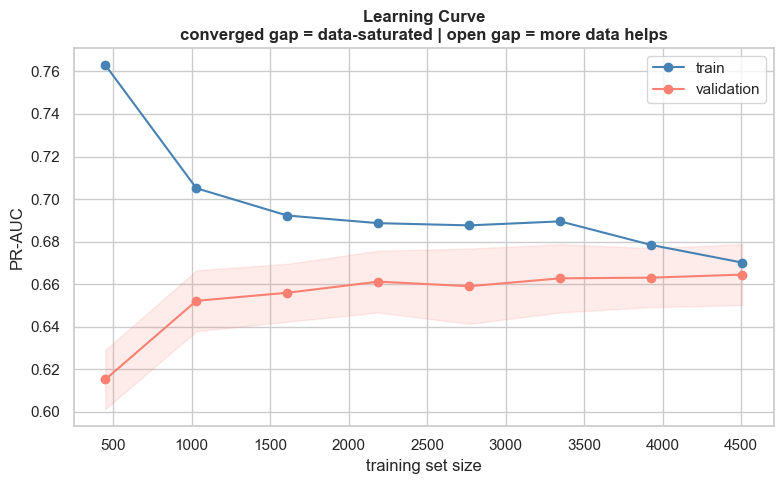

If the curves have converged -> more data will not help much; improve features instead.


In [185]:
# 2. Learning curve - does more data help?
sizes, tr, va = learning_curve(best_lr, X_train, y_train, cv=cv, scoring='average_precision',
                               train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sizes, tr.mean(1), 'o-', color='steelblue', label='train')
ax.plot(sizes, va.mean(1), 'o-', color='salmon', label='validation')
ax.fill_between(sizes, va.mean(1)-va.std(1), va.mean(1)+va.std(1), alpha=0.15, color='salmon')
ax.set_xlabel('training set size'); ax.set_ylabel('PR-AUC'); ax.legend()
ax.set_title('Learning Curve\nconverged gap = data-saturated | open gap = more data helps', fontweight='bold')
plt.tight_layout(); plt.show()
print('If the curves have converged -> more data will not help much; improve features instead.')

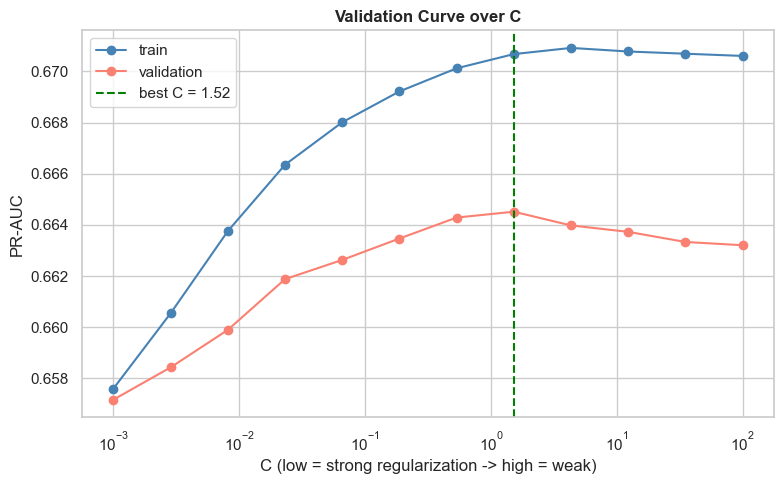

Validation PR-AUC peaks near C=1.52 then flattens - the overfit/underfit arc.


In [186]:
# 3. Validation curve over C - the regularization arc
C_range = np.logspace(-3, 2, 12)
vc_pipe = Pipeline([('pre', preprocessor),
                    ('clf', LogisticRegression(max_iter=3000, class_weight='balanced',
                                               solver='liblinear', penalty='l2', random_state=42))])
tr, va = validation_curve(vc_pipe, X_train, y_train, param_name='clf__C', param_range=C_range,
                          cv=cv, scoring='average_precision', n_jobs=-1)
best_c = C_range[va.mean(1).argmax()]
fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogx(C_range, tr.mean(1), 'o-', color='steelblue', label='train')
ax.semilogx(C_range, va.mean(1), 'o-', color='salmon', label='validation')
ax.axvline(best_c, color='green', ls='--', label=f'best C = {best_c:.3g}')
ax.set_xlabel('C (low = strong regularization -> high = weak)'); ax.set_ylabel('PR-AUC'); ax.legend()
ax.set_title('Validation Curve over C', fontweight='bold')
plt.tight_layout(); plt.show()
print(f'Validation PR-AUC peaks near C={best_c:.3g} then flattens - the overfit/underfit arc.')

## -- Project Summary: Telco Customer Churn --

**Result:** PR-AUC ~0.65, ROC-AUC ~0.84 (matches the public benchmark). Recall dialed to ~0.79 via
class_weight + threshold.

**What actually moved the needle (in order):**
1. Right metric (PR-AUC / recall) instead of accuracy
2. `class_weight='balanced'` -> recall 0.50 -> 0.79
3. Threshold tuning -> set the recall/precision operating point
4. Calibration -> honest probabilities (Brier 0.167 -> 0.138)
5. Hyperparameter tuning -> negligible (default was near-optimal)

**New skills vs P1:** imbalance handling (class_weight/SMOTE), PR-AUC, threshold tuning, probability
calibration, the row-by-row vs learns-from-data leakage rule, decision-tree visualization for interactions.

**Honest caveats:** EDA was done on the full frame (mild relaxation; stricter = train-only). Selection
across many models on one CV split carries a small optimism bias (rigorous fix = nested CV = future work).